In [1]:
import pandas as pd
import numpy as np
import csv
import matplotlib.pyplot as plt
from decimal import *
import re
import seaborn as sns

In [2]:
daily_deforestation_df = pd.read_csv('../data/deter_deforestation_notification_data_2016_2024.csv', delimiter = ',')
daily_deforestation_df

,viewDate,areaMunKm,areaUcKm,uc,uf,municipio,geocod,className
0,27/04/2023,0.07,0.0,NaN,AM,Manaus,1302603,DESMATAMENTO_VEG
1,27/04/2023,0.11,0.0,NaN,AM,Manaus,1302603,DESMATAMENTO_VEG
2,10/08/2018,0.10,0.0,NaN,AM,Manaus,1302603,DESMATAMENTO_VEG
3,23/08/2019,0.06,0.0,NaN,AM,Manaus,1302603,DESMATAMENTO_VEG
4,23/08/2019,0.07,0.0,NaN,AM,Manaus,1302603,DESMATAMENTO_VEG
...,...,...,...,...,...,...,...,...
279,18/10/2023,0.24,0.0,NaN,AM,Manaus,1302603,CICATRIZ_DE_QUEIMADA
280,18/10/2023,0.23,0.0,NaN,AM,Manaus,1302603,CICATRIZ_DE_QUEIMADA
281,18/10/2023,0.24,0.0,NaN,AM,Manaus,1302603,CICATRIZ_DE_QUEIMADA
282,09/10/2023,0.78,0.0,NaN,AM,Manaus,1302603,CICATRIZ_DE_QUEIMADA


In [3]:
daily_deforestation_df['viewDate'] = pd.to_datetime(daily_deforestation_df['viewDate'], format = '%d/%m/%Y').dt.strftime('%Y-%m-%d')
daily_deforestation_df.rename(columns={'viewDate': 'date'}, inplace=True)
daily_deforestation_df

,date,areaMunKm,areaUcKm,uc,uf,municipio,geocod,className
0,2023-04-27,0.07,0.0,NaN,AM,Manaus,1302603,DESMATAMENTO_VEG
1,2023-04-27,0.11,0.0,NaN,AM,Manaus,1302603,DESMATAMENTO_VEG
2,2018-08-10,0.10,0.0,NaN,AM,Manaus,1302603,DESMATAMENTO_VEG
3,2019-08-23,0.06,0.0,NaN,AM,Manaus,1302603,DESMATAMENTO_VEG
4,2019-08-23,0.07,0.0,NaN,AM,Manaus,1302603,DESMATAMENTO_VEG
...,...,...,...,...,...,...,...,...
279,2023-10-18,0.24,0.0,NaN,AM,Manaus,1302603,CICATRIZ_DE_QUEIMADA
280,2023-10-18,0.23,0.0,NaN,AM,Manaus,1302603,CICATRIZ_DE_QUEIMADA
281,2023-10-18,0.24,0.0,NaN,AM,Manaus,1302603,CICATRIZ_DE_QUEIMADA
282,2023-10-09,0.78,0.0,NaN,AM,Manaus,1302603,CICATRIZ_DE_QUEIMADA


In [4]:
daily_deforestation_df = daily_deforestation_df.sort_values('date', ascending=True)
daily_deforestation_df = daily_deforestation_df.drop(columns=['areaUcKm', 'uc', 'uf', 'municipio', 'geocod'])
daily_deforestation_df

,date,areaMunKm,className
93,2016-03-05,0.10,DESMATAMENTO_CR
97,2016-03-05,0.14,DESMATAMENTO_CR
96,2016-03-05,0.11,DESMATAMENTO_CR
95,2016-03-05,0.10,DESMATAMENTO_CR
94,2016-03-05,0.15,DESMATAMENTO_CR
...,...,...,...
269,2024-11-17,0.19,CICATRIZ_DE_QUEIMADA
151,2024-11-27,0.14,DESMATAMENTO_CR
273,2024-12-02,0.26,CICATRIZ_DE_QUEIMADA
272,2024-12-02,1.12,CICATRIZ_DE_QUEIMADA


In [5]:
daily_deforestation_df['className'] = (
    daily_deforestation_df['className'].replace({
        'DESMATAMENTO_VEG': 'clear_cut_primary',
        'DESMATAMENTO_CR': 'post_fire_clearcut',
        'DEGRADACAO': 'forest_degradation',
        'CICATRIZ_DE_QUEIMADA': 'burn_scar'
    })
)

daily_deforestation_df

,date,areaMunKm,className
93,2016-03-05,0.10,post_fire_clearcut
97,2016-03-05,0.14,post_fire_clearcut
96,2016-03-05,0.11,post_fire_clearcut
95,2016-03-05,0.10,post_fire_clearcut
94,2016-03-05,0.15,post_fire_clearcut
...,...,...,...
269,2024-11-17,0.19,burn_scar
151,2024-11-27,0.14,post_fire_clearcut
273,2024-12-02,0.26,burn_scar
272,2024-12-02,1.12,burn_scar


In [6]:
reset_daily_deforestation_df = daily_deforestation_df.reset_index().drop(columns='index')
reset_daily_deforestation_df

,date,areaMunKm,className
0,2016-03-05,0.10,post_fire_clearcut
1,2016-03-05,0.14,post_fire_clearcut
2,2016-03-05,0.11,post_fire_clearcut
3,2016-03-05,0.10,post_fire_clearcut
4,2016-03-05,0.15,post_fire_clearcut
...,...,...,...
279,2024-11-17,0.19,burn_scar
280,2024-11-27,0.14,post_fire_clearcut
281,2024-12-02,0.26,burn_scar
282,2024-12-02,1.12,burn_scar


In [7]:
grouped_daily_deforestation_df = (
    reset_daily_deforestation_df
    .groupby(['date', 'className'])['areaMunKm']
    .sum()
    .reset_index())

grouped_daily_deforestation_df

,date,className,areaMunKm
0,2016-03-05,forest_degradation,0.42
1,2016-03-05,post_fire_clearcut,3.55
2,2016-06-28,post_fire_clearcut,0.26
3,2016-07-27,post_fire_clearcut,0.04
4,2016-07-31,post_fire_clearcut,0.08
...,...,...,...
116,2024-10-18,post_fire_clearcut,0.33
117,2024-11-02,forest_degradation,0.26
118,2024-11-17,burn_scar,0.19
119,2024-11-27,post_fire_clearcut,0.14


In [8]:
grouped_daily_deforestation_df.loc[grouped_daily_deforestation_df['areaMunKm'].idxmax()]

date                 2022-10-04
className    forest_degradation
areaMunKm                457.56
Name: 66, dtype: object

In [9]:
reset_daily_deforestation_df[reset_daily_deforestation_df['date'] == '2022-10-04']

,date,areaMunKm,className
146,2022-10-04,0.08,post_fire_clearcut
147,2022-10-04,0.08,post_fire_clearcut
148,2022-10-04,0.17,post_fire_clearcut
149,2022-10-04,0.06,post_fire_clearcut
150,2022-10-04,0.11,post_fire_clearcut
151,2022-10-04,0.15,post_fire_clearcut
152,2022-10-04,0.12,post_fire_clearcut
153,2022-10-04,198.50,forest_degradation
154,2022-10-04,0.12,post_fire_clearcut
155,2022-10-04,70.30,forest_degradation


<Axes: xlabel='areaMunKm', ylabel='Count'>

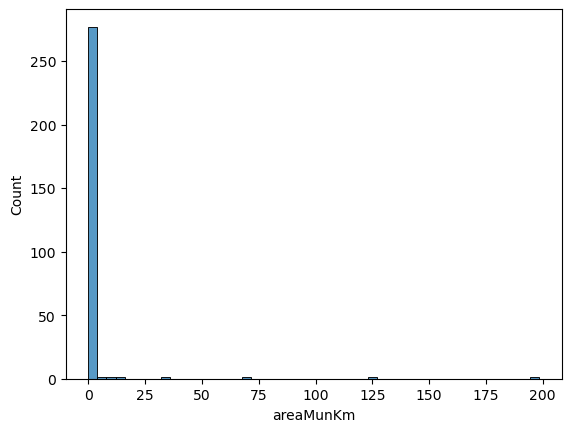

In [10]:
sns.histplot(reset_daily_deforestation_df['areaMunKm'], bins=50)

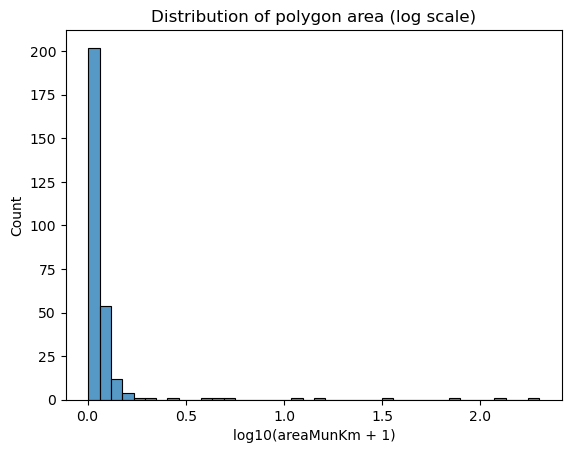

In [11]:
sns.histplot(np.log10(reset_daily_deforestation_df['areaMunKm'] + 1), bins=40)
plt.xlabel("log10(areaMunKm + 1)")
plt.title("Distribution of polygon area (log scale)")
plt.show()

In [12]:
# --- Filling Missing Dates ---

grouped_daily_deforestation_df['date'] = pd.to_datetime(
    grouped_daily_deforestation_df['date']
)

# Create full date range
all_dates = pd.date_range(start="2016-01-01", end="2024-12-31")

# Base dataframe with all dates
full_dates_df = pd.DataFrame({'date': all_dates})

# Merge with your grouped dataframe
completed_daily_deforestation_df = full_dates_df.merge(
    grouped_daily_deforestation_df,
    on='date',
    how='left'
)

# Fill missing values
completed_daily_deforestation_df['areaMunKm'] = completed_daily_deforestation_df['areaMunKm'].fillna(0)
completed_daily_deforestation_df['className'] = completed_daily_deforestation_df['className'].fillna('no_degradation')

completed_daily_deforestation_df

,date,className,areaMunKm
0,2016-01-01,no_degradation,0.0
1,2016-01-02,no_degradation,0.0
2,2016-01-03,no_degradation,0.0
3,2016-01-04,no_degradation,0.0
4,2016-01-05,no_degradation,0.0
...,...,...,...
3303,2024-12-27,no_degradation,0.0
3304,2024-12-28,no_degradation,0.0
3305,2024-12-29,no_degradation,0.0
3306,2024-12-30,no_degradation,0.0


In [13]:
completed_daily_deforestation_df['date'].nunique()

3288

In [14]:
daily_deforestation_by_class_df = (
    reset_daily_deforestation_df
    .pivot_table(
        index='date',
        columns='className',
        values='areaMunKm',
        aggfunc='sum',
        fill_value=0
    )
    .reset_index()
)

daily_deforestation_by_class_df['date'] = pd.to_datetime(daily_deforestation_by_class_df['date'])
daily_deforestation_by_class_df = daily_deforestation_by_class_df.set_index('date')

full_dates = pd.date_range('2016-01-01', '2024-12-31')

daily_deforestation_by_class_df = daily_deforestation_by_class_df.reindex(full_dates, fill_value=0.0)
daily_deforestation_by_class_df = daily_deforestation_by_class_df.reset_index().rename(columns={'index': 'date'})
daily_deforestation_by_class_df.columns.name = None
daily_deforestation_by_class_df

,date,burn_scar,clear_cut_primary,forest_degradation,post_fire_clearcut
0,2016-01-01,0.0,0.0,0.0,0.0
1,2016-01-02,0.0,0.0,0.0,0.0
2,2016-01-03,0.0,0.0,0.0,0.0
3,2016-01-04,0.0,0.0,0.0,0.0
4,2016-01-05,0.0,0.0,0.0,0.0
...,...,...,...,...,...
3283,2024-12-27,0.0,0.0,0.0,0.0
3284,2024-12-28,0.0,0.0,0.0,0.0
3285,2024-12-29,0.0,0.0,0.0,0.0
3286,2024-12-30,0.0,0.0,0.0,0.0


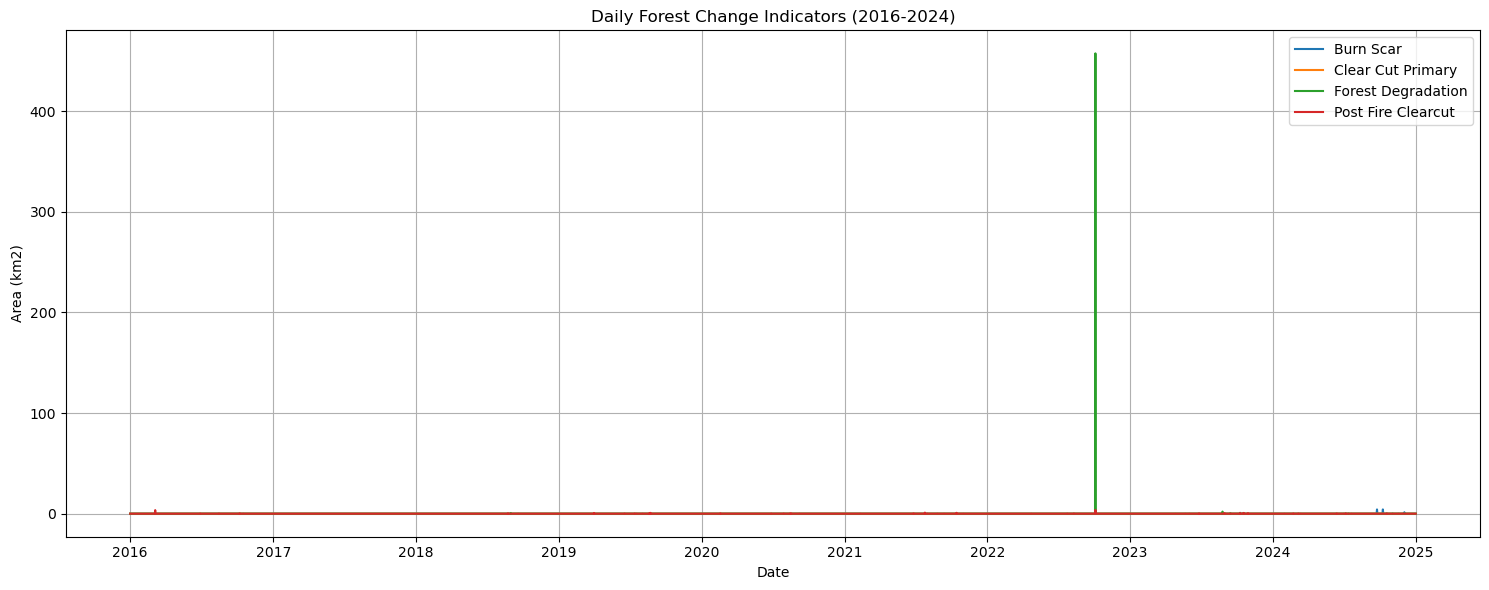

In [15]:
# Plot all four columns
plt.figure(figsize=(15, 6))
plt.plot(daily_deforestation_by_class_df['date'], daily_deforestation_by_class_df['burn_scar'], label='Burn Scar')
plt.plot(daily_deforestation_by_class_df['date'], daily_deforestation_by_class_df['clear_cut_primary'], label='Clear Cut Primary')
plt.plot(daily_deforestation_by_class_df['date'], daily_deforestation_by_class_df['forest_degradation'], label='Forest Degradation')
plt.plot(daily_deforestation_by_class_df['date'], daily_deforestation_by_class_df['post_fire_clearcut'], label='Post Fire Clearcut')

plt.xlabel('Date')
plt.ylabel('Area (km2)')
plt.title('Daily Forest Change Indicators (2016-2024)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

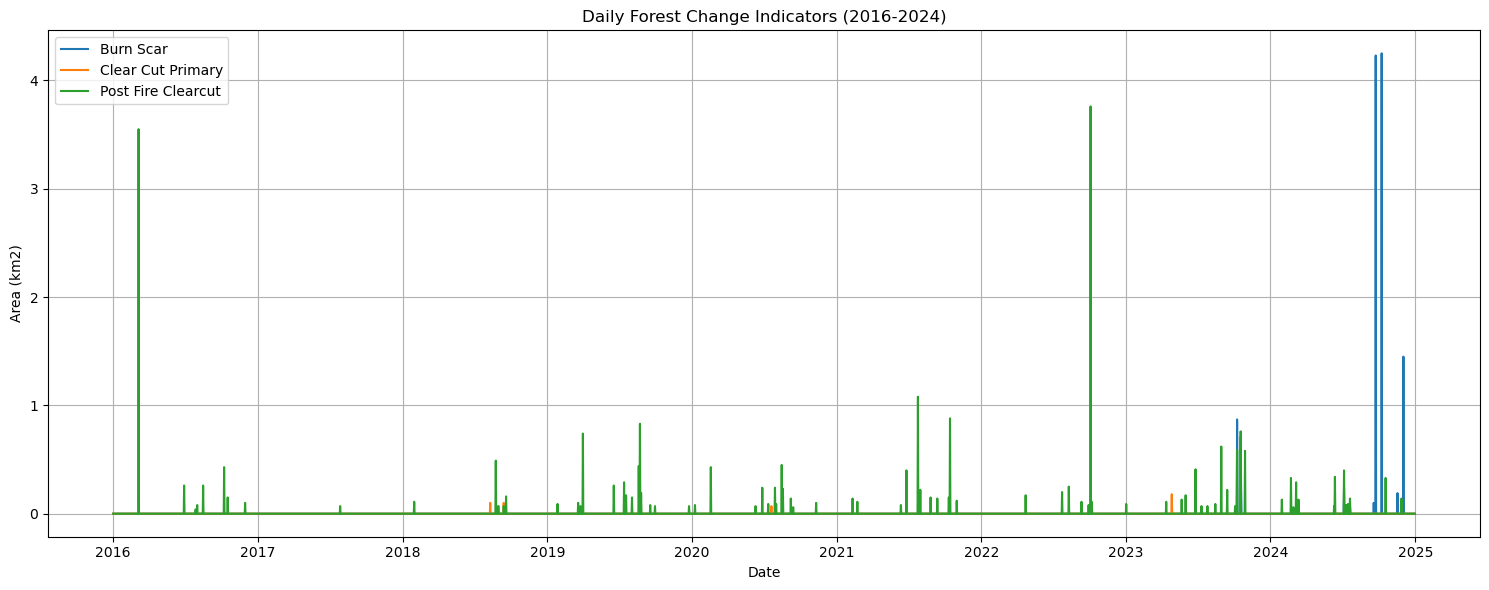

In [16]:
# Plot all four columns
plt.figure(figsize=(15, 6))
plt.plot(daily_deforestation_by_class_df['date'], daily_deforestation_by_class_df['burn_scar'], label='Burn Scar')
plt.plot(daily_deforestation_by_class_df['date'], daily_deforestation_by_class_df['clear_cut_primary'], label='Clear Cut Primary')
#plt.plot(daily_deforestation_by_class_df['date'], daily_deforestation_by_class_df['forest_degradation'], label='Forest Degradation')
plt.plot(daily_deforestation_by_class_df['date'], daily_deforestation_by_class_df['post_fire_clearcut'], label='Post Fire Clearcut')

plt.xlabel('Date')
plt.ylabel('Area (km2)')
plt.title('Daily Forest Change Indicators (2016-2024)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
daily_deforestation_by_class_df[daily_deforestation_by_class_df['date'] == '2022-10-04']

,date,burn_scar,clear_cut_primary,forest_degradation,post_fire_clearcut
2468,2022-10-04,0.0,0.0,457.56,3.76


By comparing with INPE fire counts data and searches on this case, it appears that this outlier may have been incorrectly annotated

In [19]:
daily_deforestation_by_class_df.at[2468, 'forest_degradation'] = daily_deforestation_by_class_df.at[2468, 'forest_degradation'] / 100

columns_to_sum = ['burn_scar', 'clear_cut_primary', 'forest_degradation', 'post_fire_clearcut']
daily_deforestation_by_class_df['total_degradation'] = daily_deforestation_by_class_df[columns_to_sum].sum(axis=1)

daily_deforestation_by_class_df

,date,burn_scar,clear_cut_primary,forest_degradation,post_fire_clearcut,total_degradation
0,2016-01-01,0.0,0.0,0.0,0.0,0.0
1,2016-01-02,0.0,0.0,0.0,0.0,0.0
2,2016-01-03,0.0,0.0,0.0,0.0,0.0
3,2016-01-04,0.0,0.0,0.0,0.0,0.0
4,2016-01-05,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...
3283,2024-12-27,0.0,0.0,0.0,0.0,0.0
3284,2024-12-28,0.0,0.0,0.0,0.0,0.0
3285,2024-12-29,0.0,0.0,0.0,0.0,0.0
3286,2024-12-30,0.0,0.0,0.0,0.0,0.0


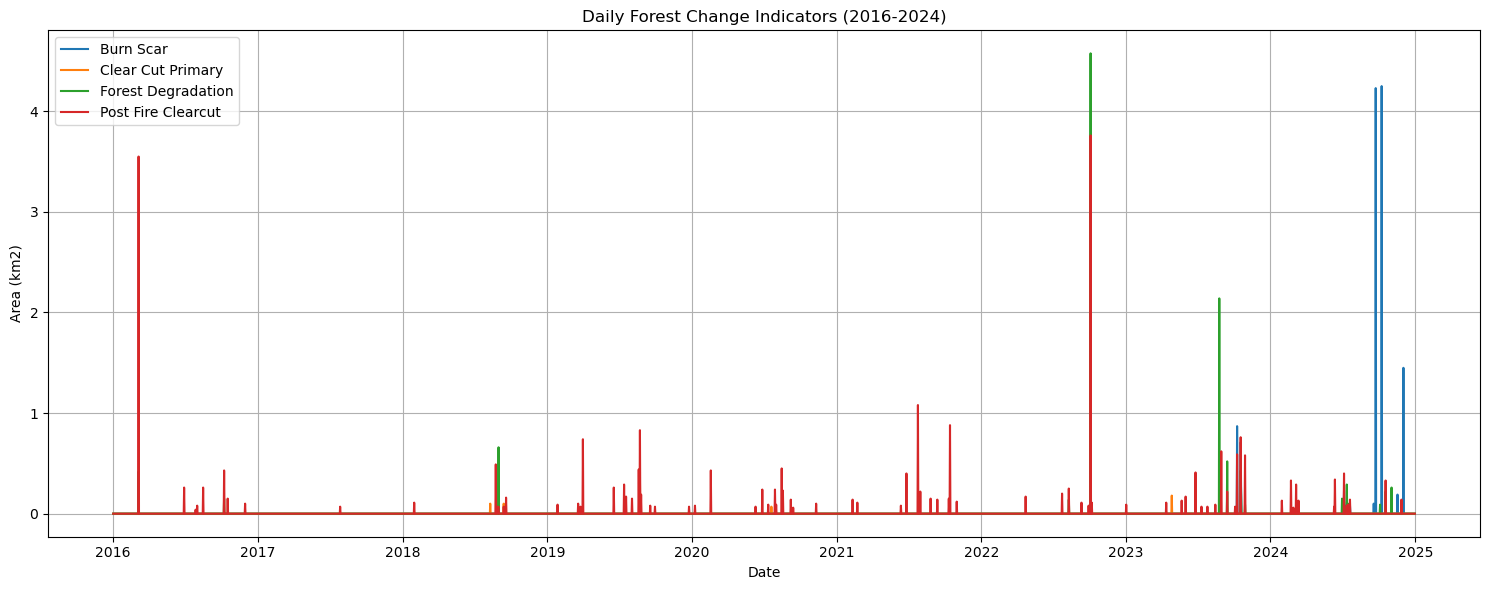

In [20]:
# Plot all four columns
plt.figure(figsize=(15, 6))
plt.plot(daily_deforestation_by_class_df['date'], daily_deforestation_by_class_df['burn_scar'], label='Burn Scar')
plt.plot(daily_deforestation_by_class_df['date'], daily_deforestation_by_class_df['clear_cut_primary'], label='Clear Cut Primary')
plt.plot(daily_deforestation_by_class_df['date'], daily_deforestation_by_class_df['forest_degradation'], label='Forest Degradation')
plt.plot(daily_deforestation_by_class_df['date'], daily_deforestation_by_class_df['post_fire_clearcut'], label='Post Fire Clearcut')

plt.xlabel('Date')
plt.ylabel('Area (km2)')
plt.title('Daily Forest Change Indicators (2016-2024)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

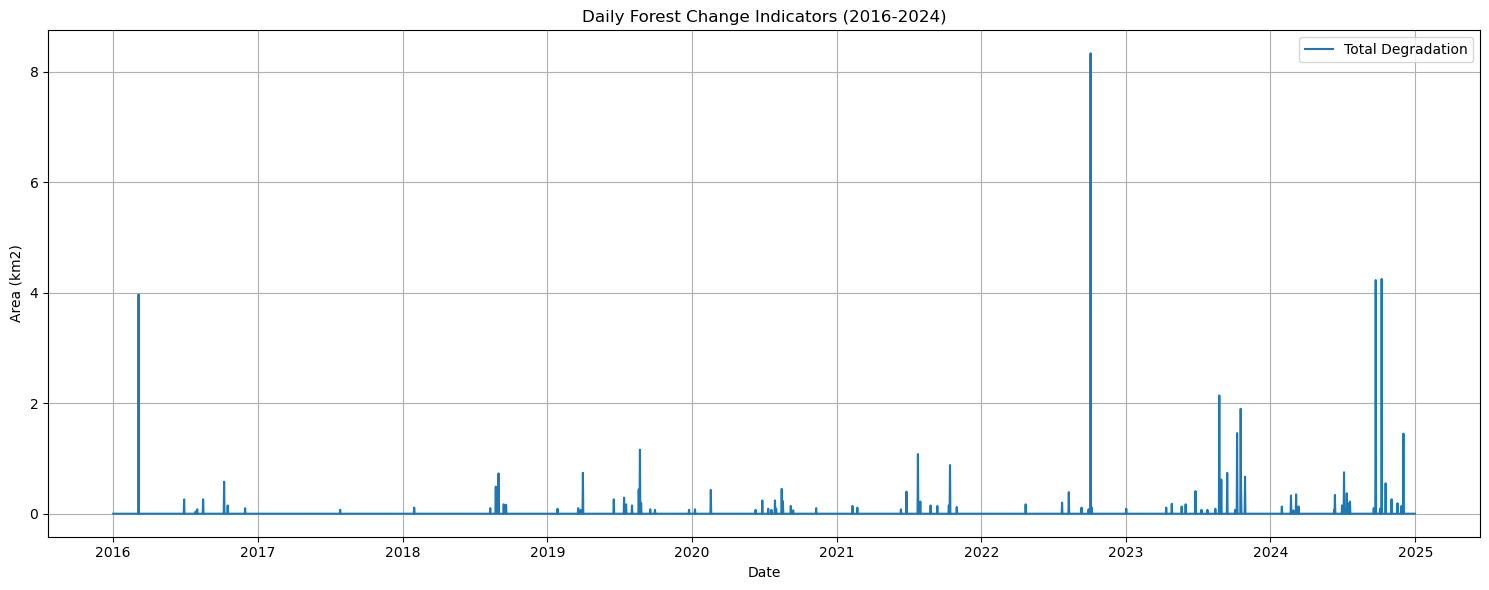

In [21]:
plt.figure(figsize=(15, 6))
plt.plot(daily_deforestation_by_class_df['date'], daily_deforestation_by_class_df['total_degradation'], label='Total Degradation')

plt.xlabel('Date')
plt.ylabel('Area (km2)')
plt.title('Daily Forest Change Indicators (2016-2024)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# Saves the dataframe as a separate csv file to be used in different modules
daily_deforestation_by_class_df.to_csv("../data/treated_deter_deforestation_data_2016_2024.csv", index=False)